In [90]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns

import matplotlib as mpl
mpl.rc('text', usetex = True)

In [17]:
data = np.random.uniform(-3,3,(300,2))
# data

z = np.dot(data,(1/np.sqrt(10),3/np.sqrt(10)))

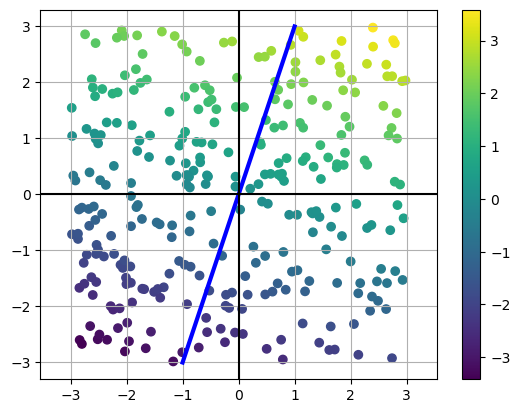

In [18]:
t = np.linspace(-1,1)
x_1 = t
x_3 = 3*t



plt.plot(x_1,x_3, linewidth = 3, color = 'blue')

plt.axis('equal')
ax = plt.gca()
ax.grid(True, which='both')


ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')

plt.scatter(data[:,0],data[:,1], c = z, cmap = 'viridis')
plt.colorbar()

plt.savefig('../Figures/DimReduction_Projection.png', bbox_inches = 'tight')

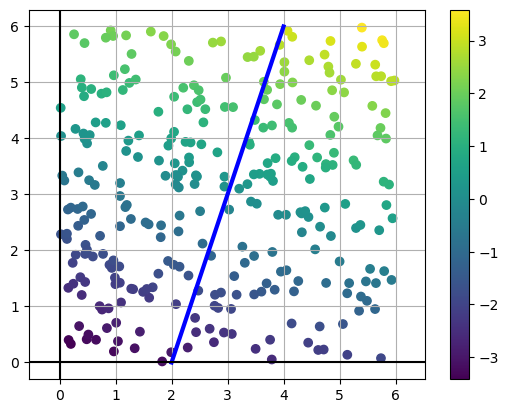

In [19]:

t = np.linspace(-1,1)
x_1 = t
x_3 = 3*t



plt.plot(x_1+3,x_3+3, linewidth = 3, color = 'blue')

plt.axis('equal')
ax = plt.gca()
ax.grid(True, which='both')


ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')

plt.scatter(data[:,0]+3,data[:,1]+3, c = z, cmap = 'viridis')
plt.colorbar()

plt.savefig('../Figures/DimReduction_Projection_Shifted.png', bbox_inches = 'tight')

In [20]:
t_data = np.random.normal(2,.5,(100,1))
eps = np.random.normal(0,1,(100,1))

data2 = np.concatenate((t_data,3*t_data+eps), axis = 1)

z2 = np.dot(data2,(1/np.sqrt(10),3/np.sqrt(10)))

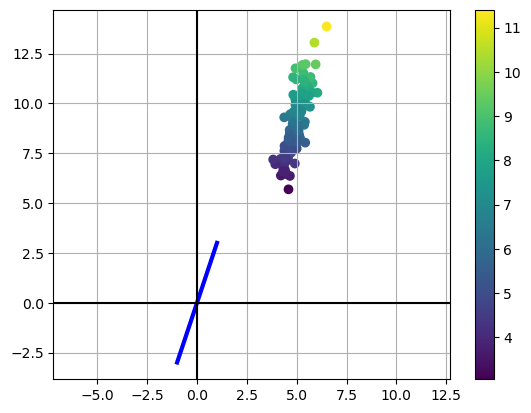

In [21]:
plt.plot(x_1,x_3, linewidth = 3, color = 'blue')

plt.axis('equal')
ax = plt.gca()
ax.grid(True, which='both')


ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')

plt.scatter(data2[:,0]+3,data2[:,1]+3, c = z2, cmap = 'viridis')
plt.colorbar()

plt.savefig('../Figures/DimReduction_Projection_Shifted.png', bbox_inches = 'tight')

[[ 6.  -3. ]
 [-3.   3.5]]


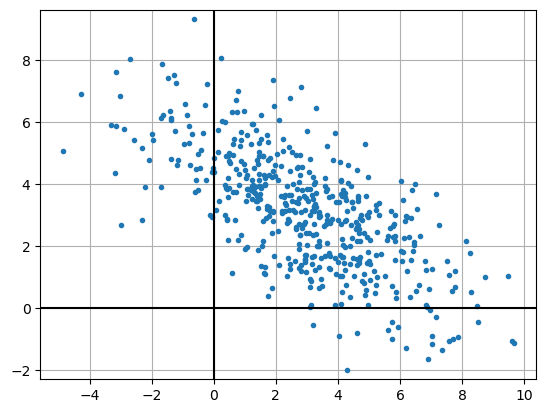

In [22]:
mean = [3,3]
cov =  np.array([[6, -3], [-3, 3.5]])
print(cov)

pts = np.random.multivariate_normal(mean, cov, 500).T

plt.plot(pts[0],pts[1], '.')

plt.axis('equal')
ax = plt.gca()
ax.grid(True, which='both')


ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')

plt.show()

# plt.savefig('../Figures/DimReduction_Projection_Example2.png', bbox_inches = 'tight')

In [23]:
X = pts.T

X.shape

(500, 2)

In [24]:
pca = PCA(n_components=2)
pca.fit(X)


PCA(n_components=2)

In [25]:
pca.components_

array([[-0.83153216,  0.55547661],
       [-0.55547661, -0.83153216]])

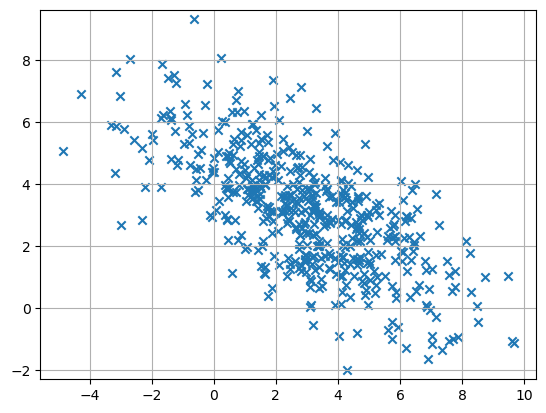

In [26]:
# mean = [3,3]
# cov =  np.array([[6, -3], [-3, 3.5]])
# print(cov)

# pts = np.random.multivariate_normal(mean, cov, 500).T

plt.scatter(X[:,0], X[:,1],marker = 'x')
plt.axis('equal')
ax = plt.gca()
ax.grid(True, which='both')

plt.savefig('../Figures/DimReduction_Projection_Example2.png', bbox_inches = 'tight')

[2.89878009 3.12287497]


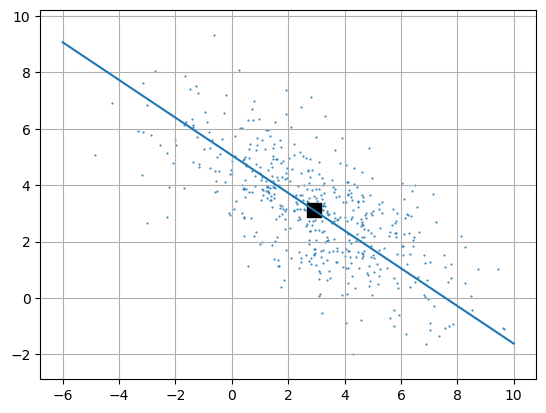

In [28]:
plt.scatter(pts[0],pts[1], marker = '.', s = 1)

plt.axis('equal')
ax = plt.gca()
ax.grid(True, which='both')


# ax.axhline(y=0, color='k')
# ax.axvline(x=0, color='k')


datamean = X.mean(axis = 0)
print(datamean)


lim = [-6,10]
for i, comp in enumerate(pca.components_):
    slope = comp[1]/comp[0]
    b = datamean[1] - slope*datamean[0]
    plt.plot(np.array(lim), slope*np.array(lim)+b)
    break
    
plt.scatter([datamean[0]],[datamean[1]], s = 100, c = 'black', marker = 's')
    
# plt.axis('square')

# plt.show()
plt.savefig('../Figures/DimReduction_Projection_Example2_line.png', bbox_inches = 'tight')

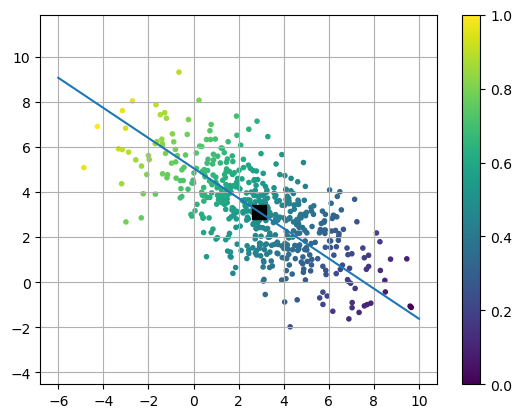

In [31]:
datamean = X.mean(axis = 0)
datacenter = X-datamean

z3 = np.dot(datacenter,pca.components_[0,:])
# print(z3)


plt.scatter(pts[0],pts[1], marker = '.',  c = z3)

plt.axis('equal')
ax = plt.gca()
ax.grid(True, which='both')

lim = [-6,10]
for i, comp in enumerate(pca.components_):
    slope = comp[1]/comp[0]
    b = datamean[1] - slope*datamean[0]
    plt.plot(np.array(lim), slope*np.array(lim)+b)
    break
    
plt.scatter([datamean[0]],[datamean[1]], s = 100, c = 'black', marker = 's')

plt.colorbar()

plt.savefig('../Figures/DimReduction_Projection_Example2_linecolor.png', bbox_inches = 'tight')

-1.1599610161283636e-15
(6.123233995736766e-17, 1.0)


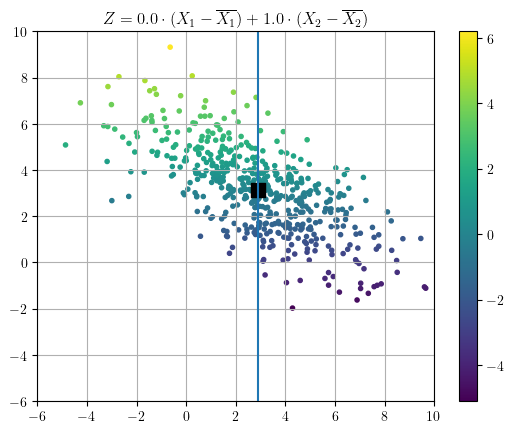

In [109]:
theta = np.pi/2    #<--- pick a number in [0,2*np.pi] My slides use 0, np.pi/4, 3*np.pi/4, np.pi/2

datamean = X.mean(axis = 0)
datacenter = X-datamean

comp = (np.cos(theta), np.sin(theta))

z3 = np.dot(datacenter,comp)
print(np.mean(z3))

plt.scatter(X[:,0], X[:,1], marker = '.',  c = z3)
plt.colorbar()


# plt.axis('equal')
plt.xlim([-6,10])
plt.ylim([-6,10])
ax = plt.gca()
ax.grid(True, which='both')

lim = [-6,10]
slope = comp[1]/comp[0]
b = datamean[1] - slope*datamean[0]
plt.plot(np.array(lim), slope*np.array(lim)+b)
    
plt.scatter([datamean[0]],[datamean[1]], s = 100, c = 'black', marker = 's')

title = r'$Z = ' + str(round(comp[0],3)) +  '\cdot(X_1 - \overline{X_1}) + ' 
title += str(round(comp[1],3)) + '\cdot(X_2 - \overline{X_2})$'
plt.title(title)
print(comp)

plt.savefig('../Figures/DimReduction_Projection_Example2_' + str(int(theta*100)) + '.png', bbox_inches = 'tight')

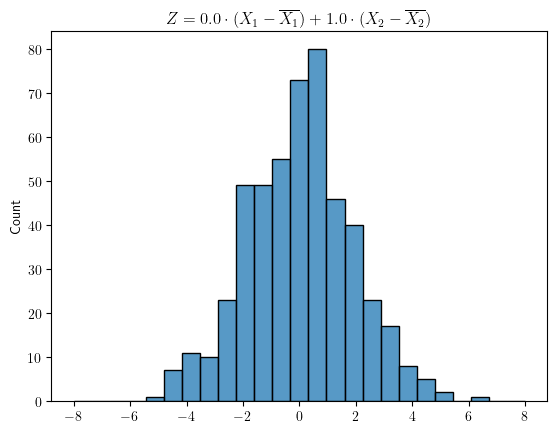

In [110]:
sns.histplot(z3,binrange = [-8,8])
plt.title(title)


plt.savefig('../Figures/DimReduction_Projection_Example2_hist' + str(int(theta*100)) + '.png', bbox_inches = 'tight')

In [77]:
?sns.histplot